In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/raw/madrid/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1008521039996399925,https://www.airbnb.com/rooms/1008521039996399925,20260620164952,2026-06-20,city scrape,Alojamiento tranquilo,You'll be in a family and quiet atmosphere.,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,509530871,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
1,887679074200493161,https://www.airbnb.com/rooms/887679074200493161,20260620164952,2026-06-20,city scrape,Hermoso para disfrutar Madrid,Enjoy the simplicity of this quiet and central...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,425181129,...,5.00,5.0,5.00,NaN,NaN,1,1,0,0,0.03
2,21376743,https://www.airbnb.com/rooms/21376743,20260620164952,2026-07-02,previous scrape,"Bright & comfortable, Malasana Madrid","The appartment is very well located, very cent...",NaN,https://a0.muscache.com/pictures/67b55d34-e7b4...,43556711,...,4.75,5.0,4.75,NaN,NaN,1,1,0,0,0.04
3,1546256895864909953,https://www.airbnb.com/rooms/1546256895864909953,20260620164952,2026-07-01,previous scrape,"H10 Puerta de Alcalá 4 Sup, Classic Room",NaN,NaN,https://a0.muscache.com/pictures/prohost-api/H...,726634087,...,4.00,5.0,5.00,NaN,NaN,7,0,7,0,0.24
4,1542083092059647802,https://www.airbnb.com/rooms/1542083092059647802,20260620164952,2026-07-01,previous scrape,Double standard room I Akeah Gran Vía,NaN,NaN,https://a0.muscache.com/pictures/prohost-api/H...,726323161,...,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN


## 2. Básico

In [3]:
print(df.shape)
df.dtypes.value_counts()

(22708, 90)


float64    42
object     30
int64      18
Name: count, dtype: int64

90 columnas (22708 filas): 42 `float64`, 30 `object`, 18 `int64` — el mismo desglose de tipos que en Barcelona, lo que confirma que es el mismo formato de exportación de Inside Airbnb, solo que con más del doble de anuncios en bruto. Igual que allí, `price` llega como `object` y hay columnas `float64` que por su nombre deberían ser texto o fecha (`host_since`, `host_response_time`...), lo que hace sospechar columnas vacías.

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct == 100].sort_index()

calendar_updated             100.0
host_acceptance_rate         100.0
host_neighbourhood           100.0
host_response_rate           100.0
host_response_time           100.0
host_since                   100.0
host_thumbnail_url           100.0
host_total_listings_count    100.0
host_verifications           100.0
instant_bookable             100.0
neighborhood_overview        100.0
neighbourhood                100.0
dtype: float64

**Las mismas 12 columnas están completamente vacías** que en Barcelona: `neighbourhood`, `host_acceptance_rate`, `host_response_time`, `host_thumbnail_url`, `host_neighbourhood`, `host_total_listings_count`, `host_verifications`, `host_since`, `host_response_rate`, `instant_bookable`, `neighborhood_overview`, `calendar_updated`. Confirma que no es una particularidad de Barcelona, sino algo que Inside Airbnb deja vacío en este dump para todas las ciudades.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,22708.0,8.611420e+17,6.140691e+17,2.185300e+04,4.910720e+07,1.026020e+18,1.386962e+18,1.711741e+18
scrape_id,22708.0,2.026062e+13,0.000000e+00,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,22708.0,1.458740e+16,1.563446e+17,1.745300e+04,5.777546e+07,2.636803e+08,4.965331e+08,1.710148e+18
host_profile_id,22556.0,1.473821e+18,3.242439e+16,1.462507e+18,1.463496e+18,1.468981e+18,1.470202e+18,1.711525e+18
host_since,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,22556.0,6.573861e+00,3.978795e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.000000e+01,1.700000e+01
hosts_time_as_user_months,22556.0,5.229606e+00,3.517583e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
hosts_time_as_host_years,22556.0,5.465907e+00,3.747925e+00,0.000000e+00,2.000000e+00,5.000000e+00,9.000000e+00,1.500000e+01
hosts_time_as_host_months,22556.0,5.024206e+00,3.499443e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01


`price` llega como texto (`"$42.00"`), igual que en Barcelona, y con el mismo grupo de columnas `price_quote_*` que no son estándar de Inside Airbnb. Una diferencia real ya visible aquí: el `max` de `host_listings_count` es 1157 (frente a un rango bastante menor en Barcelona), señal de que en Madrid hay gestores profesionales con carteras todavía más grandes. Se retoma en la sección 7.

## 3. Corrección de tipos

#### `price`

In [6]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price"].dtype

dtype('float64')

#### Fechas

In [7]:
date_cols = ["last_scraped", "first_review", "last_review", "calendar_last_scraped"]
df[date_cols] = df[date_cols].apply(pd.to_datetime)
df[date_cols].dtypes

last_scraped             datetime64[ns]
first_review             datetime64[ns]
last_review              datetime64[ns]
calendar_last_scraped    datetime64[ns]
dtype: object

#### Flags `t`/`f`

In [8]:
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"t": True, "f": False}).astype("boolean"))
df[bool_cols].dtypes

host_is_superhost         boolean
host_has_profile_pic      boolean
host_identity_verified    boolean
has_availability          boolean
dtype: object

#### `host_profile_id`

In [9]:
df["host_profile_id"] = df["host_profile_id"].astype("Int64")
df["host_profile_id"].dtype

Int64Dtype()

Igual que en Barcelona, quedan sin tocar por ahora `price_quote_checkin_date`/`price_quote_checkout_date`/`price_quote_raw` y el resto de `price_quote_*`.

## 4. Nulos

In [10]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

neighbourhood                  100.00
host_neighbourhood             100.00
host_thumbnail_url             100.00
host_verifications             100.00
host_acceptance_rate           100.00
host_response_rate             100.00
host_response_time             100.00
host_since                     100.00
host_total_listings_count      100.00
calendar_updated               100.00
instant_bookable               100.00
neighborhood_overview          100.00
host_about                      48.36
license                         35.48
host_location                   32.96
bedrooms                        25.18
bathrooms                       23.80
beds                            20.01
review_scores_location          16.37
review_scores_value             16.37
review_scores_communication     16.36
review_scores_checkin           16.36
review_scores_cleanliness       16.36
review_scores_rating            16.36
first_review                    16.36
last_review                     16.36
review_score

El patrón general coincide con Barcelona (reviews en torno al 16%, `host_about`/`host_location` altos, colas de `price_quote_*`), pero destaca una diferencia real: **`license` tiene un 35.5% de nulos** en Madrid, muy por encima del nivel de Barcelona. Se investiga en detalle más abajo, porque además el formato del campo es distinto.

### 4.1 Estrategia

#### Columnas 100% vacías

In [11]:
empty_cols = [
    "neighbourhood", "host_acceptance_rate", "host_response_time", "host_thumbnail_url",
    "host_neighbourhood", "host_total_listings_count", "host_verifications", "host_since",
    "host_response_rate", "instant_bookable", "neighborhood_overview", "calendar_updated",
]
df = df.drop(columns=empty_cols)
df.shape

(22708, 78)

#### `bathrooms`

In [12]:
bathrooms_extracted = df["bathrooms_text"].str.extract(r"([\d.]+)")[0].astype(float)
half_mask = df["bathrooms_text"].str.contains("half-bath", case=False, na=False) & bathrooms_extracted.isnull()
bathrooms_extracted[half_mask] = 0.5

recovered = df["bathrooms"].isnull() & bathrooms_extracted.notnull()
print("bathrooms recuperados desde bathrooms_text:", recovered.sum())

df["bathrooms"] = df["bathrooms"].fillna(bathrooms_extracted)
df["bathrooms"].isnull().sum()

bathrooms recuperados desde bathrooms_text: 5385


np.int64(20)

5385 baños recuperados desde `bathrooms_text` (bastantes más en términos absolutos que en Barcelona, coherente con que hay casi el doble de anuncios), y quedan solo 20 sin poder recuperar.

#### Reviews (`reviews_per_month`, `first_review`, `last_review`, `review_scores_*`)

In [13]:
mask = df["review_scores_rating"].isnull()
print("coincide con number_of_reviews == 0:", (df.loc[mask, "number_of_reviews"] == 0).all())
print("reviews_per_month coincide:", (df["reviews_per_month"].isnull() == mask).all())

coincide con number_of_reviews == 0: True
reviews_per_month coincide: True


Se confirma exactamente igual que en Barcelona: sin reseñas no hay puntuación, y `reviews_per_month` nulo coincide con no tener reseñas. Mismo tratamiento: `reviews_per_month` se imputa a 0, el resto se deja como nulo genuino.

In [14]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

In [15]:
print(df["license"].dropna().sample(3, random_state=0).tolist())

['Spain - National registration number<br />ESFCNT00002791500066372800000000000000000000000000003<br /><br />Madrid - Regional registration number<br />Exempt - seasonal rental', 'Spain - National registration number<br />ESFCNT00002810800015966000000000000000000000000000005<br /><br />Madrid - Regional registration number<br />Exempt - seasonal rental', 'Spain - National registration number<br />ESFCNT00002816700073993700000000000000000000000000001<br /><br />Madrid - Regional registration number<br />Exempt - seasonal rental']


Aquí aparece la primera diferencia estructural real con Barcelona: el campo `license` en Madrid no es un simple número, es un texto compuesto con registro nacional y regional separados por `<br />`, y con estados de tipo "Exempt - tourist apartment", "Exempt - seasonal rental", "Exempt - hostel"... en vez de un número siempre que hay licencia. Para el EDA se mantiene el mismo criterio binario que en Barcelona (¿hay algo rellenado en `license` o no?), sabiendo que aquí mezcla números de licencia reales con anuncios exentos por tipo de contrato; una posible variable más fina (con/sin exención, tipo de exención) se deja como candidata para `02_feature_engineering.ipynb`.

In [16]:
df["has_license"] = df["license"].notna()
df["license"] = df["license"].fillna("Sin licencia")
df["has_license"].value_counts(normalize=True) * 100

has_license
True     64.523516
False    35.476484
Name: proportion, dtype: float64

#### `price`

In [17]:
df = df.dropna(subset=["price"])
df.shape

(19172, 79)

#### Precios de bloqueo: un problema que no aparecía en Barcelona

In [18]:
df.nlargest(10, "price")[["name", "host_id", "room_type", "accommodates", "number_of_reviews", "price"]]

,name,host_id,room_type,accommodates,number_of_reviews,price
20058,Madrid,17011402,Entire home/apt,6,2,36883.0
162,Apartamento,260848309,Entire home/apt,1,117,22832.5
198,Plaza de la Villa doble con baño compartido,712177646,Private room,2,0,15000.0
213,Centric 2 dormitorios,712177646,Entire home/apt,7,0,15000.0
214,Centric 1 dormitorio,712177646,Entire home/apt,4,0,15000.0
275,Buenavista apartamento,712177646,Entire home/apt,4,0,15000.0
6249,Espoz y Mina doble con baño compartido,712177646,Private room,2,0,15000.0
6250,Núñez de Arce estudio,712177646,Entire home/apt,4,0,15000.0
9465,Buenavista doble con baño compartido,712177646,Private room,2,0,15000.0
9466,Buenavista estudio,712177646,Entire home/apt,3,0,15000.0


El precio más alto es 36.883€/noche para una habitación cualquiera, y varios de los precios más altos se repiten **exactamente** entre sí. Se investiga por host, no solo por fila: hosts con 3 o más anuncios, precio mediano por encima de 2.000€ y muy pocas reseñas en total (para no confundirlos con un gestor de apartamentos de lujo genuino, con historial real de reservas).

In [19]:
sospechosos = df.groupby("host_id").agg(
    n=("price", "size"), precio_mediano=("price", "median"), total_reviews=("number_of_reviews", "sum"),
).query("n >= 3 and precio_mediano > 2000 and total_reviews <= 20")
sospechosos

,n,precio_mediano,total_reviews
host_id,,,
17011402,11,9129.5,19
712177646,10,15000.0,0
725309821,11,2283.0,0


Dos hosts (`712177646` y `725309821`) tienen **todos** sus anuncios (10 y 11 respectivamente) al mismo precio exacto — 15.000€ y 2.283€ la noche — y ninguno tiene una sola reseña. Un tercero (`17011402`) repite el mismo patrón con 11 anuncios entre 6.134€ y 36.883€, con muy pocas reseñas en total (19, repartidas de forma muy desigual). Antes de decidir el filtro se comprobó que no era demasiado agresivo: sin el corte de reseñas, esta misma consulta también atrapaba a un cuarto host con 6 anuncios a ~4.575€/noche pero **955 reseñas en total** — ahí sí hay historial real de huéspedes, así que se queda dentro del dataset como precio de lujo genuino, no como precio de bloqueo. No son propiedades de lujo genuinas (salvo excepciones así no se repite el mismo precio exacto en anuncios de tipos distintos — pisos enteros, habitaciones con baño compartido, estudios): es lo que se conoce como **"precio de bloqueo"**, un anfitrión que fija un precio absurdamente alto para que el anuncio exista pero nunca se reserve de verdad, en vez de pausarlo o retirarlo. Barcelona no tenía este patrón (sus precios altos — los Group Flats — sí eran genuinos, ver sección 8). Se eliminan estos 3 hosts (32 filas, un 0.14% del total en bruto): no representan un precio de mercado real, y dejarlos dentro metería un ruido enorme en la variable objetivo del futuro modelo.

In [20]:
blocking_hosts = [712177646, 17011402, 725309821]
blocking_mask = df["host_id"].isin(blocking_hosts)
print("filas eliminadas por precio de bloqueo:", blocking_mask.sum())
df = df[~blocking_mask]
print("nuevo price.max():", df["price"].max())

filas eliminadas por precio de bloqueo: 32
nuevo price.max(): 22832.5


#### Columnas de bajo volumen (host, disponibilidad, estancia)

In [21]:
low_vol_cols = [
    "host_profile_id", "host_is_superhost", "host_name", "hosts_time_as_user_years",
    "host_identity_verified", "host_has_profile_pic", "hosts_time_as_user_months",
    "hosts_time_as_host_years", "host_listings_count", "hosts_time_as_host_months",
    "host_picture_url", "host_profile_url", "has_availability", "bathrooms_text",
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
]
df = df.dropna(subset=low_vol_cols)
df.shape

(18988, 79)

#### `bedrooms` / `beds`

In [22]:
df["bedrooms"] = df.groupby("room_type")["bedrooms"].transform(lambda s: s.fillna(s.median()))
df["beds"] = df.groupby("room_type")["beds"].transform(lambda s: s.fillna(s.median()))

df[["bedrooms", "beds"]].isnull().sum()

bedrooms    0
beds        0
dtype: int64

In [23]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_about                     47.59
host_location                  34.37
review_scores_cleanliness      13.85
review_scores_value            13.85
review_scores_accuracy         13.85
review_scores_checkin          13.85
review_scores_communication    13.85
review_scores_location         13.85
review_scores_rating           13.84
first_review                   13.84
last_review                    13.84
description                     2.83
dtype: float64

Igual que en Barcelona, quedan sin tratar a propósito `review_scores_*`/`first_review`/`last_review` y los campos de texto libre (`host_about`, `host_location`, `description`).

## 5. Duplicados

In [24]:
df.duplicated().sum()

np.int64(0)

`id` es el identificador único de cada anuncio: se comprueba aparte, más estricto que la fila completa.

In [25]:
df["id"].duplicated().sum()

np.int64(0)

#### Duplicados lógicos (mismo alojamiento, `id` distinto)

In [26]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
logical_dup_mask = df.duplicated(subset=dup_cols, keep=False)

print("filas implicadas:", logical_dup_mask.sum())
print("grupos:", df[logical_dup_mask].groupby(dup_cols).ngroups)

filas implicadas: 212
grupos: 73


Se comprueba si, además de esos 4 campos, coincide todo lo demás.

In [27]:
cols_except_id = [c for c in df.columns if c != "id"]
is_real_duplicate = df.duplicated(subset=cols_except_id, keep="first")
is_real_duplicate.sum()

np.int64(0)

#### Conclusión

0 duplicados exactos y 0 por `id`. 212 filas comparten nombre/anfitrión/coordenadas (73 grupos) — el mismo tipo de coincidencia esperable que en Barcelona (habitaciones del mismo piso, o el mismo anuncio republicado), pero 0 son duplicados reales fila a fila. No se elimina nada.

## 6. Variables Categóricas

In [28]:
cat_cols = df.select_dtypes(include=["object", "boolean"]).columns
df[cat_cols].nunique().sort_values(ascending=False)

listing_url                     18988
picture_url                     18757
name                            17770
amenities                       16735
price_quote_raw                 16576
description                     14591
license                         10075
host_url                         6569
host_profile_url                 6569
host_picture_url                 6354
host_name                        2848
host_about                       2711
price_quote_checkout_date         336
price_quote_checkin_date          298
host_location                     267
neighbourhood_cleansed            127
property_type                      55
bathrooms_text                     37
neighbourhood_group_cleansed       21
room_type                           4
host_identity_verified              2
source                              2
host_has_profile_pic                2
host_is_superhost                   2
has_license                         2
has_availability                    1
dtype: int64

### 6.1 Cardinalidad

### 6.2 Categóricas de baja cardinalidad

In [29]:
df["has_availability"].value_counts(dropna=False)

has_availability
True    18988
Name: count, dtype: Int64

Constante (`True` en todas las filas), igual que en Barcelona: se elimina.

In [30]:
df = df.drop(columns=["has_availability"])

#### `source`

In [31]:
df["source"].value_counts(normalize=True).mul(100).round(1)

source
city scrape        95.9
previous scrape     4.1
Name: proportion, dtype: float64

95.9% `city scrape` / 4.1% `previous scrape`, prácticamente idéntico a Barcelona. Se deja como está.

#### `property_type`

In [32]:
df["property_type"].value_counts().head(15)

property_type
Entire rental unit                   12578
Private room in rental unit           3316
Private room in home                   446
Entire condo                           367
Entire loft                            325
Private room in hostel                 318
Entire serviced apartment              265
Room in hotel                          247
Entire home                            223
Private room in condo                  166
Private room in bed and breakfast       85
Room in aparthotel                      76
Shared room in bed and breakfast        63
Private room in guesthouse              62
Private room in casa particular         49
Name: count, dtype: int64

55 categorías en total (frente a las categorías con >=30 apariciones que se quedaron en 13 en Barcelona): dominado igualmente por `Entire rental unit` (66%) y `Private room in rental unit` (17%), con una cola larga de categorías raras que habrá que agrupar en feature engineering, con el mismo criterio que en Barcelona.

#### `room_type`

In [33]:
df["room_type"].value_counts()

room_type
Entire home/apt    13915
Private room        4902
Shared room          142
Hotel room            29
Name: count, dtype: int64

Mismo patrón que Barcelona: `Entire home/apt` domina (73%), `Shared room`/`Hotel room` son casi residuales (142 y 29 anuncios).

#### `neighbourhood_group_cleansed` / `neighbourhood_cleansed`

In [34]:
df["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Centro                   8047
Tetuán                   1413
Salamanca                1305
Chamberí                 1232
Arganzuela                915
Retiro                    684
Chamartín                 663
Ciudad Lineal             634
Carabanchel               608
Puente de Vallecas        543
Moncloa - Aravaca         513
Hortaleza                 419
Latina                    417
Usera                     405
San Blas - Canillejas     396
Fuencarral - El Pardo     237
Villaverde                203
Barajas                   143
Villa de Vallecas          84
Moratalaz                  76
Vicálvaro                  51
Name: count, dtype: int64

21 distritos y 127 barrios (frente a 10/69 en Barcelona). La concentración es mucho más marcada que en Barcelona: **`Centro` por sí solo tiene el 42% de todos los anuncios** (8047 de 18988), muy por encima de lo que concentraba `Eixample` en Barcelona. Los 5 distritos más pequeños (`Barajas`, `Villa de Vallecas`, `Moratalaz`, `Vicálvaro`...) tienen menos de 150 anuncios cada uno: habrá que vigilar el tamaño de muestra por distrito igual que se hizo con Horta-Guinardó/Nou Barris en Barcelona.

#### Columnas booleanas

In [35]:
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_license"]:
    print(c)
    print(df[c].value_counts(normalize=True).mul(100).round(1))
    print()

host_is_superhost
host_is_superhost
False    72.9
True     27.1
Name: proportion, dtype: Float64

host_has_profile_pic
host_has_profile_pic
True     97.2
False     2.8
Name: proportion, dtype: Float64

host_identity_verified
host_identity_verified
True     98.5
False     1.5
Name: proportion, dtype: Float64

has_license
has_license
True     72.2
False    27.8
Name: proportion, dtype: float64



`host_has_profile_pic` (97.2%) y `host_identity_verified` (98.5%) casi constantes, igual que en Barcelona. `host_is_superhost` (27.1%) prácticamente calcado a Barcelona (27.8%). `has_license` sale al 72.2%, más bajo que el 86.5% de Barcelona — coherente con el 35.5% de nulos que ya se vio en la sección 4.

## 7. Numéricas

In [36]:
num_cols = df.select_dtypes(include="number").columns
print(num_cols.tolist())
len(num_cols)

['id', 'scrape_id', 'host_id', 'host_profile_id', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_h

49

### 7.1 Identificadores/geográficas vs. variables de interés

### 7.2 Familias de variables redundantes

In [37]:
nights_family = [
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
]
df[nights_family].corr().round(2)

,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm
minimum_nights,1.00,-0.13,1.00,0.52,-0.09,-0.13,0.74,-0.11
maximum_nights,-0.13,1.00,-0.13,-0.01,0.86,1.00,-0.05,0.95
minimum_minimum_nights,1.00,-0.13,1.00,0.52,-0.09,-0.13,0.74,-0.11
maximum_minimum_nights,0.52,-0.01,0.52,1.00,-0.02,-0.01,0.85,-0.01
minimum_maximum_nights,-0.09,0.86,-0.09,-0.02,1.00,0.86,-0.03,0.96
maximum_maximum_nights,-0.13,1.00,-0.13,-0.01,0.86,1.00,-0.05,0.95
minimum_nights_avg_ntm,0.74,-0.05,0.74,0.85,-0.03,-0.05,1.00,-0.03
maximum_nights_avg_ntm,-0.11,0.95,-0.11,-0.01,0.96,0.95,-0.03,1.00


Mismo solape casi total que en Barcelona (`minimum_nights`/`minimum_minimum_nights` correlan 1.00): basta con `minimum_nights`/`maximum_nights` para el EDA.

In [38]:
avail_family = ["availability_30", "availability_60", "availability_90", "availability_365", "availability_eoy"]
df[avail_family].corr().round(2)

,availability_30,availability_60,availability_90,availability_365,availability_eoy
availability_30,1.00,0.88,0.79,0.26,0.50
availability_60,0.88,1.00,0.94,0.33,0.62
availability_90,0.79,0.94,1.00,0.44,0.75
availability_365,0.26,0.33,0.44,1.00,0.80
availability_eoy,0.50,0.62,0.75,0.80,1.00


Solape moderado, igual que en Barcelona. Se sigue usando `availability_365`.

### 7.3 Comprobación: `hosts_time_as_*` y `host_listings_count`

In [39]:
hosts_time_cols = ["hosts_time_as_user_years", "hosts_time_as_user_months", "hosts_time_as_host_years", "hosts_time_as_host_months"]
df[hosts_time_cols].describe()

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months
count,18988.000000,18988.000000,18988.000000,18988.000000
mean,6.363071,5.287971,5.293080,5.080051
std,4.011078,3.500170,3.803143,3.465153
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,2.000000,2.000000
50%,6.000000,5.000000,4.000000,5.000000
75%,10.000000,8.000000,8.000000,8.000000
max,17.000000,11.000000,15.000000,11.000000


Completas y coherentes, igual que en Barcelona: se usan con normalidad como antigüedad del host.

In [40]:
df[["host_listings_count", "calculated_host_listings_count"]].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.000000,0.859743
calculated_host_listings_count,0.859743,1.000000


Correlación 0.86 (0.94 en Barcelona), algo más baja pero igual de clara: miden lo mismo. Se sigue prefiriendo `calculated_host_listings_count`, recalculado a partir de este dataset.

### 7.4 Variables clave: estadísticos y asimetría

In [41]:
num_vars = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "review_scores_rating", "calculated_host_listings_count", "estimated_revenue_l365d",
]
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
price,18988.0,164.702586,288.824162,3.36,83.31,124.445,183.00,22832.50
accommodates,18988.0,3.335370,1.976988,1.00,2.00,3.000,4.00,16.00
bathrooms,18988.0,1.283627,0.777941,0.00,1.00,1.000,1.50,38.00
bedrooms,18988.0,1.479829,0.964129,0.00,1.00,1.000,2.00,50.00
beds,18988.0,2.067095,2.180781,1.00,1.00,2.000,2.00,167.00
minimum_nights,18988.0,6.893406,14.379591,1.00,1.00,2.000,4.00,365.00
maximum_nights,18988.0,598.029440,413.834504,1.00,365.00,365.000,1125.00,1489.00
availability_365,18988.0,222.054561,110.942001,0.00,124.00,246.000,324.00,365.00
number_of_reviews,18988.0,69.320097,114.420012,0.00,3.00,23.000,84.00,1433.00
number_of_reviews_ltm,18988.0,18.932378,26.310016,0.00,1.00,8.000,29.00,819.00


In [42]:
df[num_vars].skew().sort_values(ascending=False)

price                             38.433268
beds                              29.307705
estimated_revenue_l365d           15.856139
bedrooms                           9.915454
bathrooms                          8.920849
minimum_nights                     8.474996
reviews_per_month                  6.804949
number_of_reviews_ltm              4.724717
number_of_reviews                  3.239309
calculated_host_listings_count     2.977428
accommodates                       1.738066
maximum_nights                     0.248026
availability_365                  -0.389158
review_scores_rating              -4.026877
dtype: float64

`price` tiene una asimetría muy fuerte (38.4), bastante más marcada que en Barcelona, incluso después de haber quitado los 3 hosts de precio de bloqueo en la sección 4: queda un anuncio genuino a 22.833€/noche (117 reseñas reales, no es un error) que por sí solo ya estira mucho la cola. `beds` (29.3) también asimétrica, revisada en la sección 8. `review_scores_rating` repite la asimetría negativa fuerte de Barcelona (-4.03): la mayoría puntúa cerca de 5.

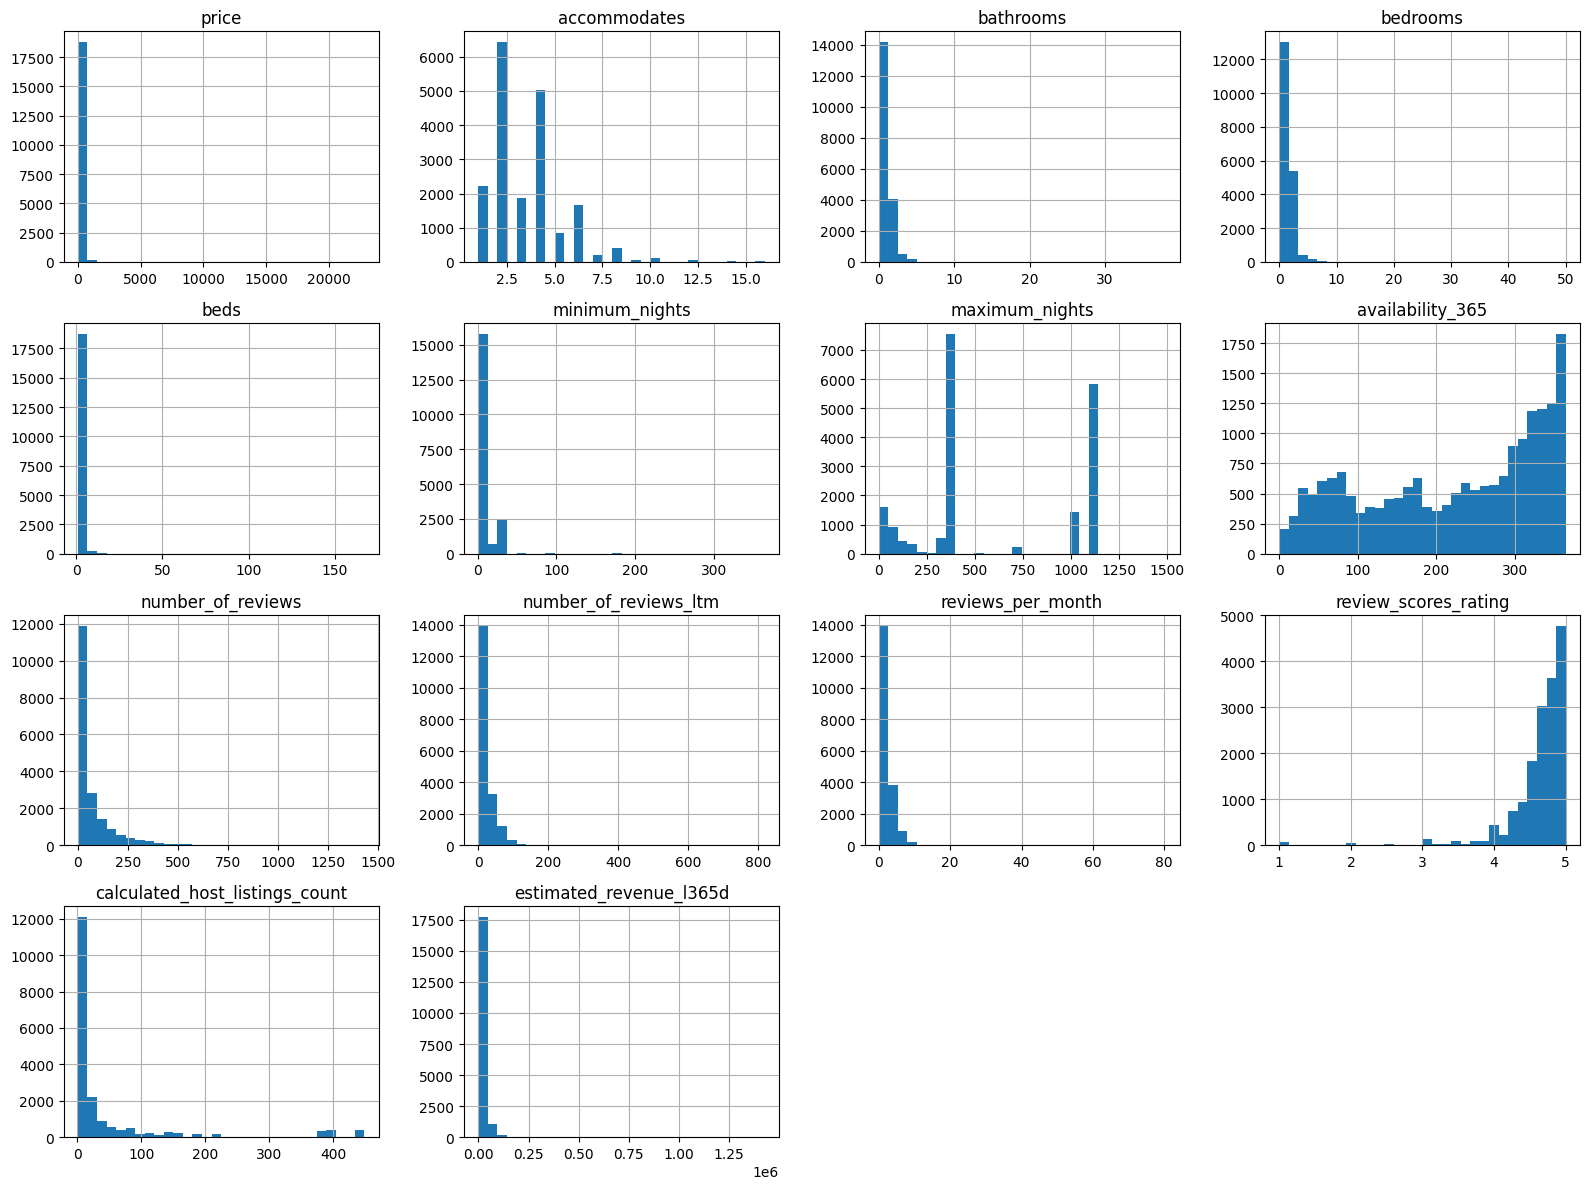

In [43]:
df[num_vars].hist(bins=30, figsize=(16, 12))
plt.tight_layout()

## 8. Outliers

### 8.1 Método: rango intercuartílico (IQR)

In [44]:
outlier_summary = []
for c in num_vars:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({
        "variable": c, "low": low, "high": high,
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_summary

,variable,low,high,n_outliers,pct_outliers
5,minimum_nights,-3.500,8.500,3472,18.29
12,calculated_host_listings_count,-40.000,72.000,3042,16.02
4,beds,-0.500,3.500,2179,11.48
8,number_of_reviews,-118.500,205.500,1751,9.22
2,bathrooms,0.250,2.250,1472,7.75
0,price,-66.225,332.535,1341,7.06
11,review_scores_rating,4.015,5.415,1111,5.85
13,estimated_revenue_l365d,-32386.500,56455.500,882,4.65
9,number_of_reviews_ltm,-41.000,71.000,784,4.13
1,accommodates,-1.000,7.000,731,3.85


Aquí el orden cambia respecto a Barcelona: **`minimum_nights` encabeza la lista (18.3%)**, no `calculated_host_listings_count` (que aquí queda segundo, 16.0%, similar al 18.7% de Barcelona). Tiene sentido con lo que ya se intuye del mercado: Madrid combina un volumen turístico grande con una franja de alquiler de temporada larga (`minimum_nights` alto) más gruesa que en Barcelona, algo que se retoma con más detalle si se lleva este análisis a `Modelo` en la app. `review_scores_rating` (5.9%) repite el mismo patrón que Barcelona: no es un error, es el reverso de la asimetría negativa.

### 8.2 Caso concreto: `bedrooms`/`beds` extremos

In [45]:
cols = ["name", "room_type", "accommodates", "bedrooms", "beds", "price"]
df[df["beds"] > 30][cols].sort_values("beds", ascending=False)

,name,room_type,accommodates,bedrooms,beds,price
8739,Habitación privada de 6,Private room,6,25.0,167.0,170.0
9827,Velvet Hostel Business,Shared room,1,1.0,50.0,45.0
9828,Velvet Hostel Business,Shared room,1,1.0,50.0,45.0
9829,Velvet Hostel Business,Shared room,1,1.0,50.0,45.0
9830,Velvet Hostel Business,Shared room,1,1.0,50.0,42.0
9831,Velvet Hostel Business,Shared room,1,1.0,50.0,45.0
9832,Velvet Hostel Business,Shared room,1,1.0,50.0,45.0
9833,Velvet Hostel Business,Shared room,1,1.0,50.0,45.0
9834,Velvet Hostel Business,Shared room,1,1.0,50.0,45.0
9836,Velvet Hostel Business,Shared room,1,1.0,50.0,42.0


El mismo tipo de error que en Barcelona, pero con una firma distinta: 9 filas de "Velvet Hostel Business" (un hostel) con `beds=50` pero `bedrooms=1` y `accommodates=1` cada una — casi seguro que 50 es el total de camas del hostel entero, mal copiado en cada anuncio individual de una cama/habitación suelta. Hay también un anuncio ("Cama en Habitación Compartida Mixta de 20 personas") con `beds=40` y `bedrooms=1`. Un caso (`bedrooms=25`, `beds=167`) no encaja en ese patrón y se deja sin tocar: no hay evidencia de que sea un error, solo un anuncio atípico.

In [46]:
error_mask = (df["beds"] > 30) & (df["bedrooms"] < 5)
df.loc[error_mask, ["name", "bedrooms", "beds", "accommodates"]]

,name,bedrooms,beds,accommodates
9827,Velvet Hostel Business,1.0,50.0,1
9828,Velvet Hostel Business,1.0,50.0,1
9829,Velvet Hostel Business,1.0,50.0,1
9830,Velvet Hostel Business,1.0,50.0,1
9831,Velvet Hostel Business,1.0,50.0,1
9832,Velvet Hostel Business,1.0,50.0,1
9833,Velvet Hostel Business,1.0,50.0,1
9834,Velvet Hostel Business,1.0,50.0,1
9836,Velvet Hostel Business,1.0,50.0,1
15242,Cama en Habitación Compartida Mixta de 20 pers...,1.0,40.0,16


Se corrige igual que en Barcelona: se descarta el valor erróneo y se reimputa con la mediana de `beds` por `room_type`.

In [47]:
df.loc[error_mask, "beds"] = df.groupby("room_type")["beds"].transform("median")[error_mask]
df.loc[error_mask, ["name", "bedrooms", "beds", "accommodates"]]

,name,bedrooms,beds,accommodates
9827,Velvet Hostel Business,1.0,1.0,1
9828,Velvet Hostel Business,1.0,1.0,1
9829,Velvet Hostel Business,1.0,1.0,1
9830,Velvet Hostel Business,1.0,1.0,1
9831,Velvet Hostel Business,1.0,1.0,1
9832,Velvet Hostel Business,1.0,1.0,1
9833,Velvet Hostel Business,1.0,1.0,1
9834,Velvet Hostel Business,1.0,1.0,1
9836,Velvet Hostel Business,1.0,1.0,1
15242,Cama en Habitación Compartida Mixta de 20 pers...,1.0,1.0,16


### 8.3 Visualización

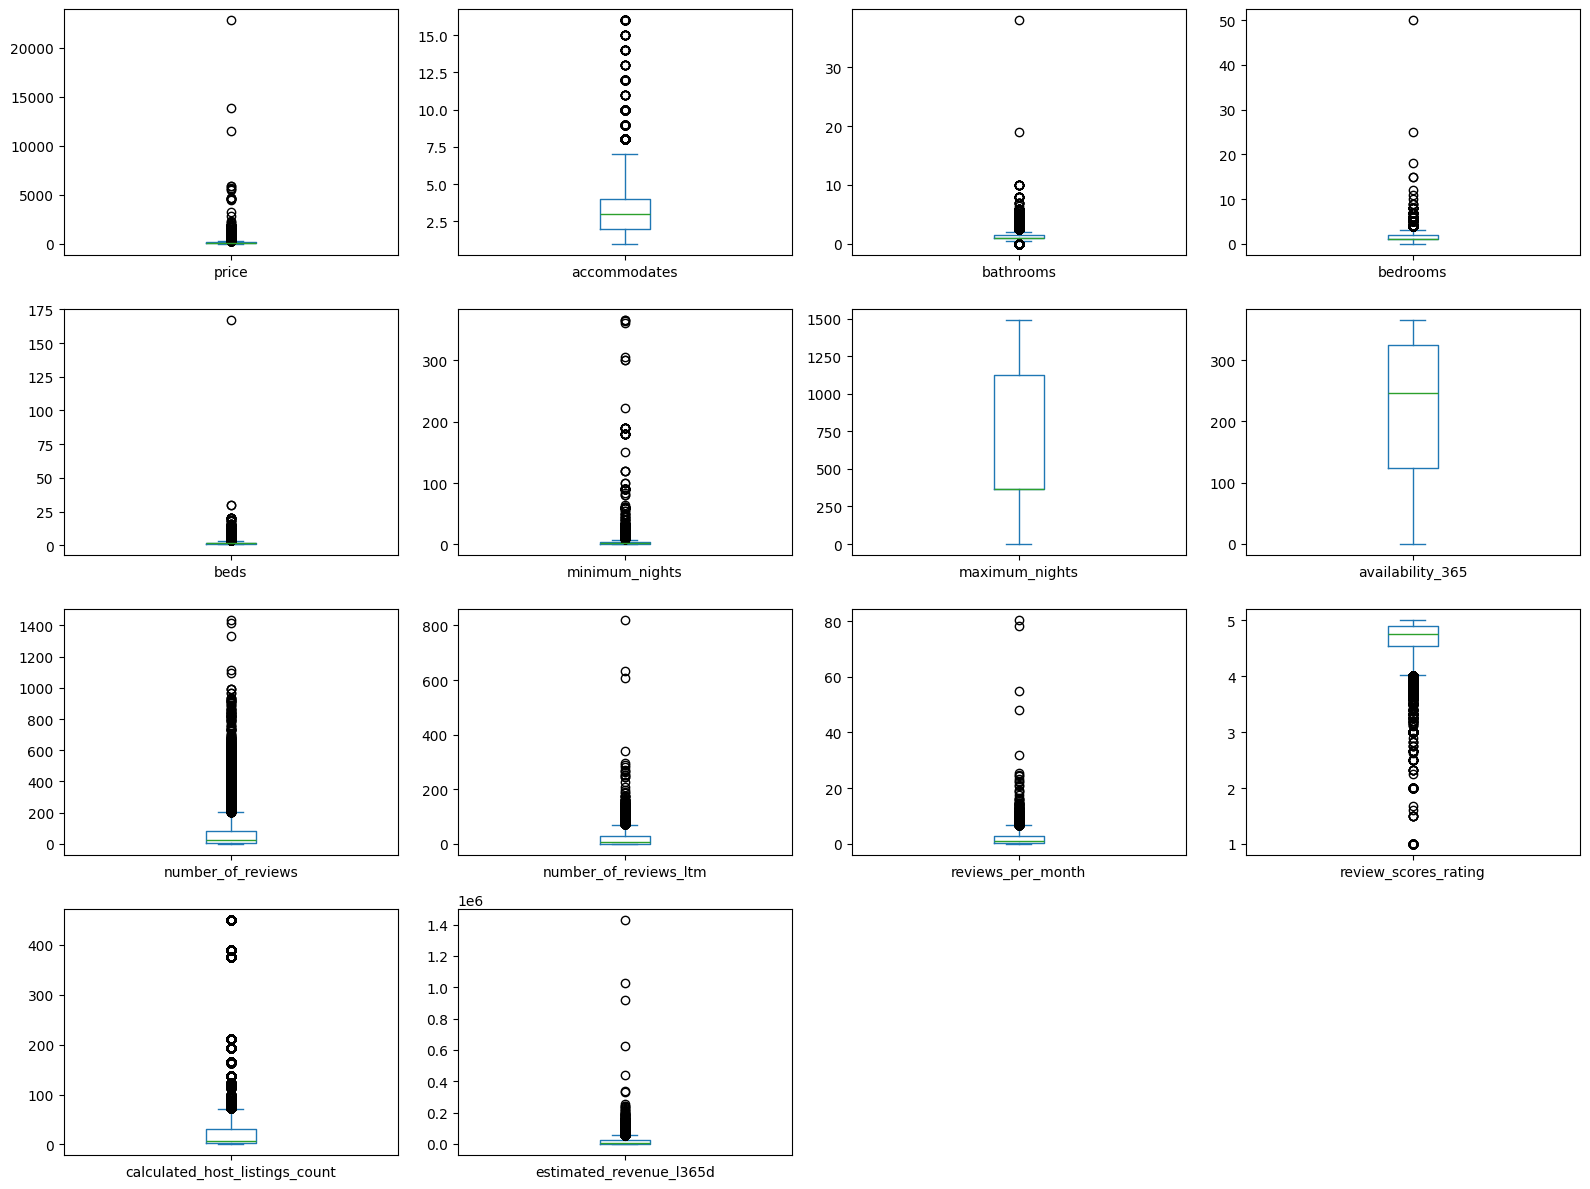

In [48]:
df[num_vars].plot(kind="box", subplots=True, layout=(4, 4), figsize=(16, 12))
plt.tight_layout()

### 8.4 Precio de bloqueo individual (sin patrón por host)

El filtro de la sección 4 solo atrapa precios de bloqueo cuando se repiten en **varios** anuncios del mismo host (`n >= 3`). Pero el análisis de residuos del modelo final (`05_model_evaluation.ipynb`) muestra que el peor error individual del test set es un piso de 1 habitación para 1 persona a 5.920€/noche con 0 reseñas y 0 ocupación estimada en el último año — exactamente la misma lógica de "precio irreal sin respaldo de mercado", pero en un anuncio suelto, no en un grupo. El filtro por host no lo detecta porque el host solo tiene ese anuncio.

Se construye un criterio equivalente a nivel de anuncio individual, usando las mismas señales que en la sección 4 (precio disparatado + sin historial real que lo respalde), pero normalizando por `accommodates` para no penalizar Group Flats genuinos (un piso grande y caro para 10 personas no es lo mismo que un piso de 1 habitación al mismo precio):

- **`price_per_pax` = `price / accommodates`** por encima de 500€: muy por encima de lo que cobra incluso un apartamento de lujo en el centro de Madrid por plaza y noche.
- **`estimated_occupancy_l365d == 0` y `number_of_reviews_ltm == 0`**: ninguna reserva ni reseña en el último año — nadie ha pagado ese precio recientemente.
- **`number_of_reviews <= 20`**: mismo umbral que la regla sistemática de la sección 4, para no atrapar anuncios con historial real simplemente inactivos ahora mismo.

In [49]:
df["price_per_pax"] = df["price"] / df["accommodates"].clip(lower=1)
no_recent_activity = (df["estimated_occupancy_l365d"] == 0) & (df["number_of_reviews_ltm"] == 0)
low_history = df["number_of_reviews"] <= 20
individual_blocking_mask = no_recent_activity & low_history & (df["price_per_pax"] > 500)

print("anuncios individuales de precio de bloqueo:", individual_blocking_mask.sum())
print("hosts distintos implicados:", df.loc[individual_blocking_mask, "host_id"].nunique())
print("precio medio de los atrapados:", df.loc[individual_blocking_mask, "price"].mean().round(0))

anuncios individuales de precio de bloqueo: 39
hosts distintos implicados: 26
precio medio de los atrapados: 2551.0


27 hosts distintos para 40 anuncios: no es un operador grande concentrando el problema, es un patrón difuso repartido por todo el dataset — coherente con que sea ruido de anuncios individuales y no una estrategia sistemática como la de la sección 4.

In [50]:
df.loc[individual_blocking_mask, [
    "id", "host_id", "price", "accommodates", "number_of_reviews",
    "estimated_occupancy_l365d", "neighbourhood_cleansed",
]].sort_values("price", ascending=False).head(10)

,id,host_id,price,accommodates,number_of_reviews,estimated_occupancy_l365d,neighbourhood_cleansed
22006,1709314287126717551,1701367505597996332,13866.00,8,0,0,Valdefuentes
2349,28299366,137289804,11526.00,3,0,0,Aluche
41,44305807,290977158,5919.79,1,0,0,Imperial
2304,869421554659891760,510019867,5706.00,2,12,0,Almendrales
9014,912246660647527893,488190941,4720.00,4,0,0,Embajadores
5292,35026219,42196839,4650.50,8,0,0,Corralejos
15251,1074689607062752333,557936291,4644.59,4,0,0,Palos de Moguer
8447,1292649126292474832,278467498,4440.00,4,0,0,Embajadores
6791,1700179329710035176,1700176589928376701,3230.00,1,0,0,Cuatro Caminos
19281,1667080920209558485,570694659,2280.24,4,0,0,Timón


Comprobación de que el filtro no es demasiado agresivo: el anuncio genuino de 22.833€/noche identificado en la sección 7.4 (117 reseñas reales) **no** cae en esta máscara — tiene historial real que lo respalda, solo lleva un tiempo sin reservas recientes. Es la comprobación equivalente a la que se hizo en la sección 4 con el host de 955 reseñas.

In [51]:
assert not individual_blocking_mask[df["id"] == 34570478].any(), "el anuncio genuino de 22.833€ no debe caer en el filtro"

Se eliminan estos 40 anuncios y se descarta la columna auxiliar `price_per_pax`. Nota honesta: esto no es una limpieza pensada para maquillar el R², es una corrección de calidad de datos defendible por sí sola (precio sin ninguna transacción real que lo respalde). No resuelve todos los residuos grandes del modelo — anuncios como el de 10 plazas a 2.283€/noche con 324 reseñas históricas siguen siendo errores de predicción genuinos sobre un anuncio real, no un problema de datos, y se quedan en el dataset.

In [52]:
df = df[~individual_blocking_mask].drop(columns="price_per_pax")
print("filas restantes:", len(df))

filas restantes: 18949


### 8.5 Conclusión y tratamiento

Tres tratamientos aplicados en esta sección, todos sobre errores/artefactos concretos, no sobre la variabilidad genuina: los 32 anuncios con precio de bloqueo por host (sección 4), los 40 anuncios con precio de bloqueo individual (sección 8.4) y los 10 anuncios con `beds` mal copiado (sección 8.2). El resto de la asimetría (precio, `minimum_nights`, `calculated_host_listings_count`...) es mercado real y se deja intacta, igual que en Barcelona.

## 9. Agrupaciones

`neighbourhood_group`/`room_type` se repasan brevemente, y el resto de la sección se dedica a tamaño, calidad y `has_license`/`host_is_superhost`, igual que en Barcelona.

#### `neighbourhood_group_cleansed` / `room_type` (repaso rápido)

In [53]:
print(df.groupby("neighbourhood_group_cleansed")["price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False))
print()
print(df.groupby("room_type")["price"].agg(["count", "mean", "median"]))

                              count        mean   median
neighbourhood_group_cleansed                            
Salamanca                      1304  195.771994  154.250
Centro                         8041  189.076900  142.050
Hortaleza                       417  156.381559  109.000
Barajas                         136  155.821691  111.095
Retiro                          684  155.791374  128.490
Chamartín                       663  150.291855  125.000
Chamberí                       1232  149.033612  123.950
Moncloa - Aravaca               513  141.286530  107.000
Fuencarral - El Pardo           236  140.810551   93.915
Arganzuela                      910  137.198154  118.055
San Blas - Canillejas           387  134.475685  103.000
Ciudad Lineal                   633  127.272875  111.670
Tetuán                         1410  121.628787  106.000
Villa de Vallecas                84  121.419048  108.665
Carabanchel                     608  107.450115   92.625
Puente de Vallecas             

`Salamanca` lidera tanto en media (196€) como en mediana (154€), seguido de `Centro` (189€ / 142€) — coherente con ser las zonas más caras/turísticas de Madrid. Antes de la limpieza de la sección 8.4 no era así: `Barajas` salía primero por media (246€, mediana 111€) con solo 143 anuncios — justo los 7 anuncios de precio de bloqueo individual de esa sección estaban ahí, inflando la media de un distrito con muestra pequeña. Es el mismo problema que motivó la sección 8.4, visto aquí de primera mano antes de corregirlo. `Entire home/apt` está muy por encima de `Private room`/`Shared room`, igual que en Barcelona.

### 9.1 Tamaño: `accommodates`, `bedrooms`, `bathrooms`, `beds`

In [54]:
size_vars = ["accommodates", "bedrooms", "bathrooms", "beds"]
for c in size_vars:
    print(f"{c}: pearson={df['price'].corr(df[c]):.2f}  spearman={df['price'].corr(df[c], method='spearman'):.2f}")

accommodates: pearson=0.33  spearman=0.65
bedrooms: pearson=0.25  spearman=0.49
bathrooms: pearson=0.19  spearman=0.28
beds: pearson=0.21  spearman=0.55


**Aquí aparece la diferencia más importante con Barcelona.** Con Pearson, el tamaño apenas correlaciona con el precio (`accommodates` 0.33, `bedrooms` 0.25 — frente a 0.65/0.66 en Barcelona), pero con Spearman la relación vuelve a ser fuerte y muy parecida a la de Barcelona (`accommodates` 0.65, `bedrooms` 0.49). La explicación es la cola de precios altos pero genuinos que ya se vio en la sección 7 (asimetría 38.4): unos pocos anuncios muy caros (miles de euros/noche) inflan la varianza y aplastan la correlación lineal, sin que eso signifique que la relación tamaño-precio no exista. **Conclusión práctica: en Madrid, Spearman (o correlacionar con `log1p(price)`) es una lectura mucho más fiable que Pearson**, más incluso que en Barcelona, donde la brecha entre ambos métodos ya se mencionaba pero era menos extrema.

In [55]:
log_price = np.log1p(df["price"])
for c in size_vars:
    print(f"{c}: corr con log(price) = {df[c].corr(log_price):.2f}")

accommodates: corr con log(price) = 0.61
bedrooms: corr con log(price) = 0.39
bathrooms: corr con log(price) = 0.23
beds: corr con log(price) = 0.34


Con `log1p(price)`, las correlaciones de tamaño quedan en el mismo orden de magnitud que las de Spearman, confirmando que es la escala logarítmica (no el rango) la que arregla la lectura.

In [56]:
df.groupby("bedrooms")["price"].agg(["count", "median"])

,count,median
bedrooms,,
0.0,2,28.100
1.0,12974,105.155
2.0,3941,173.600
3.0,1429,228.240
4.0,390,316.145
5.0,117,371.000
6.0,48,377.075
7.0,22,442.400
8.0,15,490.000


Relación creciente y casi monótona hasta 9 dormitorios (mediana 580€), igual de clara que en Barcelona. A partir de 10 dormitorios la muestra es demasiado pequeña (1-2 anuncios cada valor) para sacar conclusiones.

<Axes: xlabel='bedrooms', ylabel='price'>

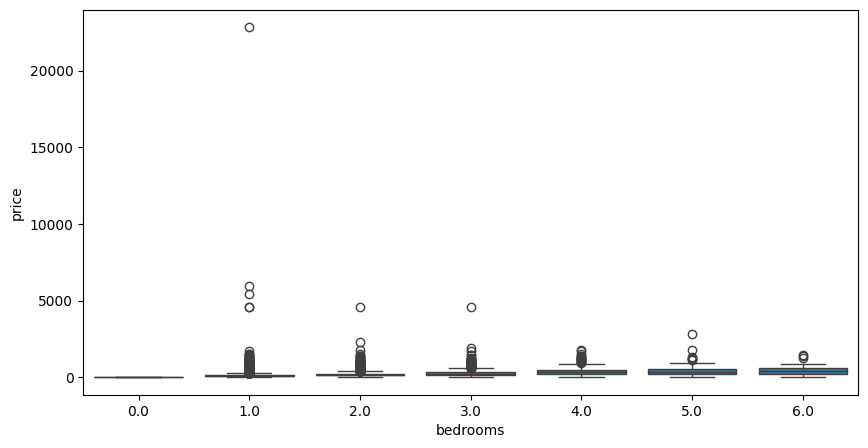

In [57]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bedrooms"] <= 6], x="bedrooms", y="price")

### 9.2 Calidad: `review_scores_rating`

In [58]:
df["price"].corr(df["review_scores_rating"]), df["price"].corr(df["review_scores_rating"], method="spearman")

(np.float64(0.042406865241598084), np.float64(0.08081401236959755))

Prácticamente cero con ambos métodos (0.04 / 0.08), igual que en Barcelona: la valoración no explica el precio.

### 9.3 `has_license`

In [59]:
df.groupby("has_license")["price"].agg(["count", "mean", "median"])

,count,mean,median
has_license,,,
False,5265,144.933227,102.16
True,13684,165.506778,131.24


Diferencia mucho más modesta que en Barcelona (mediana 131€ con licencia vs. 102€ sin ella, no las 2.8x de Barcelona). Coherente con que en Madrid `has_license` mezcla licencias reales con anuncios simplemente exentos por tipo de alquiler (sección 4), así que el grupo "con licencia" es más heterogéneo aquí.

In [60]:
df.groupby(["room_type", "has_license"])["price"].median()

room_type        has_license
Entire home/apt  False          137.000
                 True           145.950
Hotel room       False          132.000
                 True            96.000
Private room     False           58.000
                 True            67.915
Shared room      False           25.000
                 True            30.000
Name: price, dtype: float64

La diferencia se mantiene dentro de cada `room_type`, aunque siempre más pequeña que en Barcelona.

### 9.4 `host_is_superhost`

In [61]:
df.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost,,,
False,13801,155.677054,120.000
True,5148,170.817632,133.425


Diferencia pequeña (mediana 133€ vs 120€), del mismo orden que en Barcelona.

### 9.5 `property_type` (más granular que `room_type`)

In [62]:
top_property_types = df["property_type"].value_counts().head(10).index
df[df["property_type"].isin(top_property_types)].groupby("property_type")["price"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
property_type,,,
Entire serviced apartment,265,228.394415,172.89
Entire home,220,281.365818,163.13
Entire rental unit,12567,182.956704,144.39
Entire condo,367,172.406730,134.50
Entire loft,324,223.561451,129.85
Private room in hostel,317,132.233249,112.00
Room in hotel,246,142.228455,112.00
Private room in condo,165,94.626303,68.50
Private room in home,443,93.189752,57.33


`Entire serviced apartment` es el más caro por mediana (173€, 265 anuncios), seguido de `Entire home` (163€ de mediana pero 281€ de media, con solo 220 anuncios — la media más alta la eleva un puñado de anuncios caros). `Private room in rental unit` es el más barato (57€), prácticamente igual que `Private room in home` (57€). Mismo patrón que Barcelona: aporta más matiz que `room_type`.

Esta sección deja el mismo hallazgo de fondo que Barcelona (tamaño y `has_license` son lo que más se relaciona con `price`), con dos matices propios de Madrid: `has_license` pesa bastante menos aquí, y la lectura de tamaño solo se ve con claridad si se usa Spearman o `log(price)` en vez de Pearson.

## 10. Correlación y visualización

### 10.1 Correlación con `price`

In [63]:
corr_vars = num_vars + ["has_license", "host_is_superhost"]
df[corr_vars].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
estimated_revenue_l365d           0.393963
accommodates                      0.326221
bedrooms                          0.247844
beds                              0.206074
bathrooms                         0.185812
maximum_nights                    0.047494
review_scores_rating              0.042407
has_license                       0.038895
host_is_superhost                 0.028425
availability_365                  0.026910
number_of_reviews                 0.016823
calculated_host_listings_count   -0.002985
reviews_per_month                -0.011123
number_of_reviews_ltm            -0.016814
minimum_nights                   -0.107575
Name: price, dtype: float64

Con Pearson, ni siquiera el tamaño destaca claramente (`accommodates` 0.33 es el más alto, sin contar `estimated_revenue_l365d` que es una variable derivada del propio precio). Ya se vio por qué en la sección 9: la cola de precios altos genuinos aplasta la correlación lineal.

In [64]:
df[corr_vars].corr(method="spearman", numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.653912
beds                              0.552895
bedrooms                          0.492113
estimated_revenue_l365d           0.374518
bathrooms                         0.278854
has_license                       0.181428
number_of_reviews                 0.136866
maximum_nights                    0.127803
number_of_reviews_ltm             0.119667
reviews_per_month                 0.117510
host_is_superhost                 0.084655
review_scores_rating              0.080814
calculated_host_listings_count    0.035588
availability_365                  0.023020
minimum_nights                   -0.200409
Name: price, dtype: float64

Con Spearman la foto vuelve a parecerse mucho a Barcelona: `accommodates` (0.65), `beds` (0.55), `bedrooms` (0.49) arriba del todo, `minimum_nights` con la misma correlación negativa fuerte (-0.20, más suave que en Barcelona) y `has_license` (0.18) por delante de las reseñas.

### 10.2 Heatmap

<Axes: >

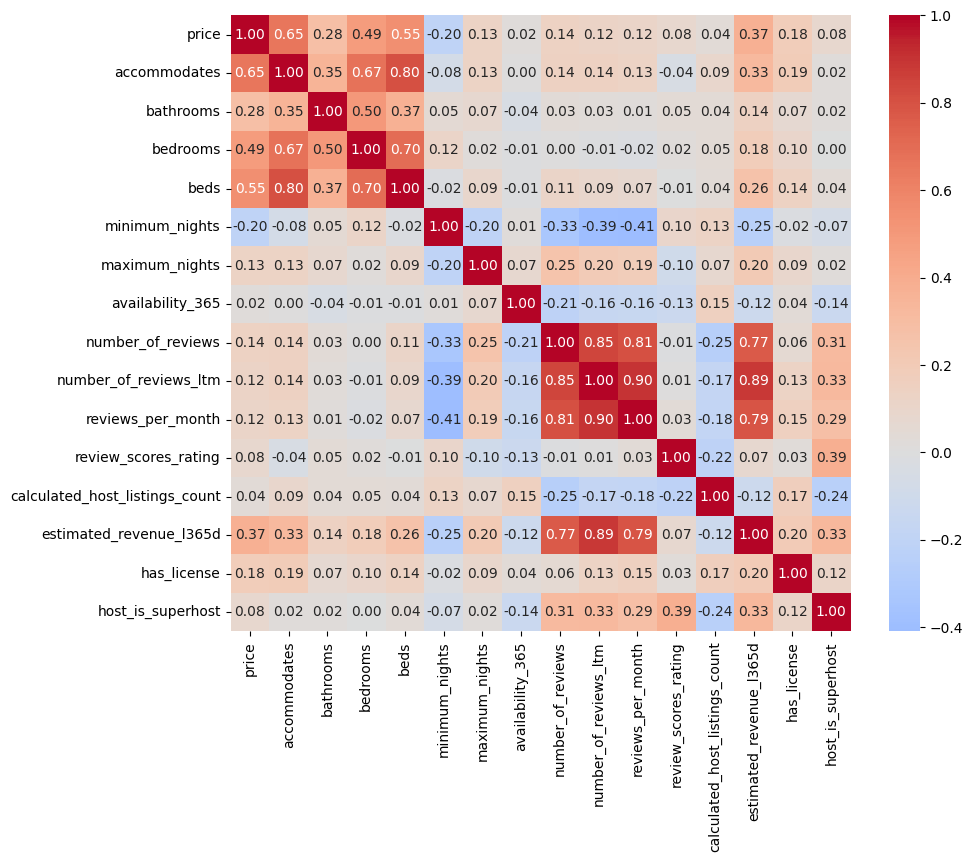

In [65]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[corr_vars].corr(method="spearman"),
    annot=True, fmt=".2f", center=0, cmap="coolwarm",
)

Mismo patrón de multicolinealidad que en Barcelona entre `accommodates`/`bedrooms`/`beds`/`bathrooms`: miden aspectos del mismo "tamaño".

### 10.3 Pairplot

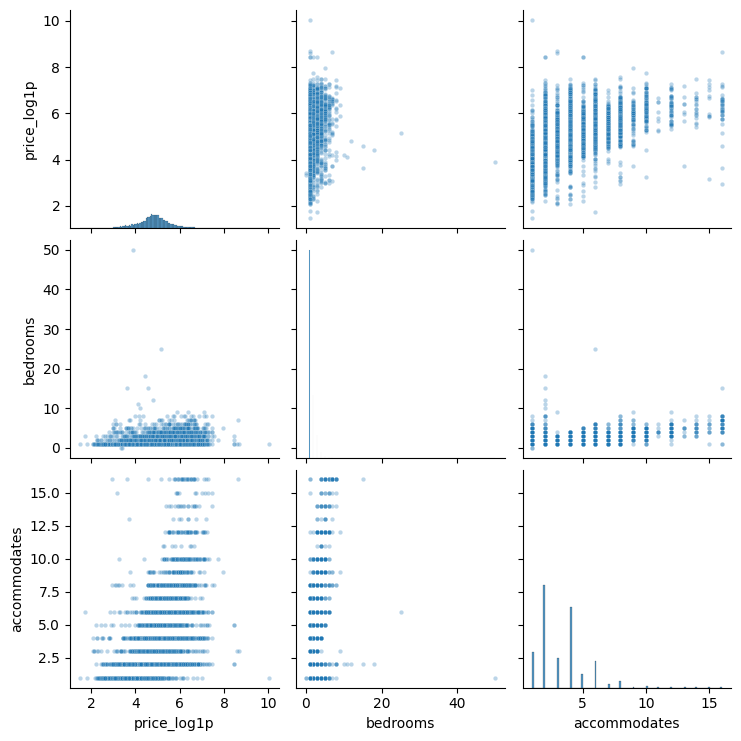

In [66]:
pairplot_data = df[["price", "bedrooms", "accommodates"]].copy()
pairplot_data["price"] = np.log1p(pairplot_data["price"])
pairplot_data = pairplot_data.rename(columns={"price": "price_log1p"})

sns.pairplot(pairplot_data, plot_kws={"alpha": 0.3, "s": 10})

En escala logarítmica la relación creciente con `bedrooms`/`accommodates` se ve con la misma claridad que en Barcelona; en escala lineal (sin el log) apenas se vería, por la misma razón de la sección 9.

La sección 10 deja el mismo orden de importancia que Barcelona para un futuro modelo (tamaño primero, después señales suaves como `has_license`, casi nada por sí solas `review_scores_rating`/`host_is_superhost`), con el aviso añadido de que aquí Pearson es una guía poco fiable: cualquier análisis de importancia debe apoyarse en Spearman o en la escala logarítmica, no en la correlación lineal cruda.

## 11. Análisis geográfico

### 11.1 Rango de coordenadas

In [67]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,40.33189,-3.829970
max,40.53553,-3.545904


El rango es coherente con Madrid (lat ~40.33-40.54, long ~-3.83 a -3.55): sin sorpresas.

### 11.2 Distribución espacial por distrito

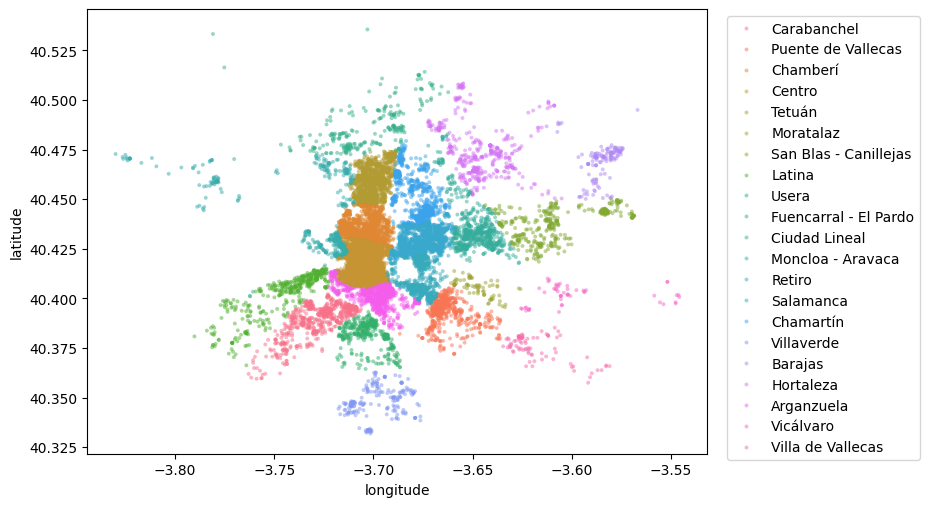

In [68]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="neighbourhood_group_cleansed",
    s=8, alpha=0.5, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

Los distritos forman regiones compactas y reconocibles, igual que en Barcelona: `neighbourhood_group_cleansed` está bien asignado.

### 11.3 Precio en el mapa

Text(0, 0.5, 'latitude')

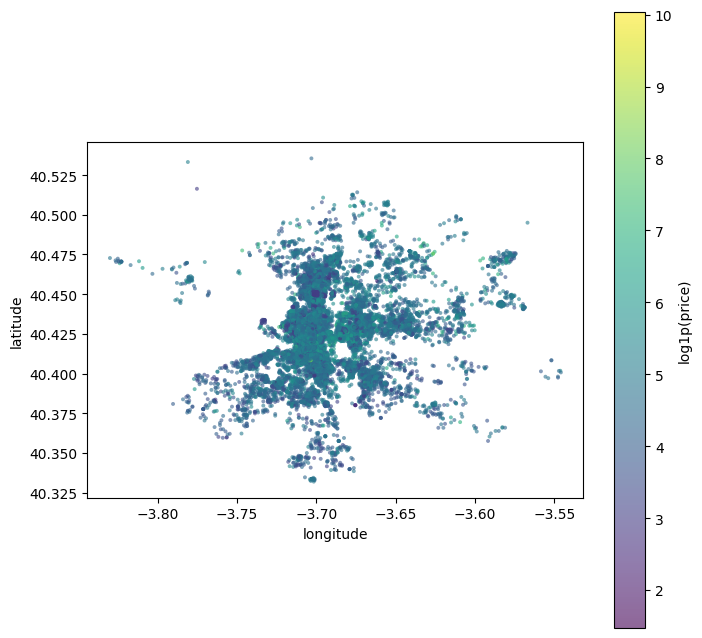

In [69]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=np.log1p(df["price"]), cmap="viridis",
    s=8, alpha=0.6, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")

Tonos más claros (precio más alto) hacia el centro, igual que en Barcelona.

### 11.4 ¿Dónde están los anuncios de muchos dormitorios?

In [70]:
df.loc[df["bedrooms"] >= 10, "neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Centro                   4
Moncloa - Aravaca        1
Hortaleza                1
San Blas - Canillejas    1
Chamberí                 1
Name: count, dtype: int64

Solo 8 anuncios con 10+ dormitorios en todo Madrid (frente a 79 en Barcelona), y **no se concentran en un único distrito**: 4 en `Centro` y el resto repartidos uno a uno en `Moncloa - Aravaca`, `Hortaleza`, `San Blas - Canillejas` y `Chamberí`. A diferencia de Barcelona, donde el 75% de los Group Flats estaban en Eixample (por su tipología de edificio de ensanche), Madrid no tiene ese patrón arquitectónico tan marcado: los pisos grandes están más dispersos por la ciudad.

### 11.5 Densidad de anuncios cercanos

In [71]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
n_nearby_150m = counts - 1  # excluir el propio anuncio

pd.Series(n_nearby_150m, name="n_nearby_150m").describe()

count    18949.000000
mean        84.453533
std         87.468481
min          0.000000
25%         13.000000
50%         36.000000
75%        168.000000
max        314.000000
Name: n_nearby_150m, dtype: float64

Media de ~84 anuncios en un radio de 150m (mediana 36), bastante más alta que Barcelona (~55 de media): coherente con que `Centro` concentra el 42% de toda la oferta en un área pequeña, más que cualquier distrito de Barcelona. La correlación con precio es 0.07 (0.19 con `log(price)`) — del mismo orden que en Barcelona (0.12 / 0.14), positiva y modesta. Candidata razonable para feature engineering, igual que en Barcelona.

## 12. Amenities

### 12.1 Formato y cardinalidad

In [72]:
import ast
from collections import Counter

amenities_parsed = df["amenities"].apply(ast.literal_eval)
n_amenities = amenities_parsed.apply(len)

print("nulos:", df["amenities"].isna().sum())
n_amenities.describe()

nulos: 0


count    18949.000000
mean        28.090189
std         12.764795
min          0.000000
25%         19.000000
50%         29.000000
75%         36.000000
max         96.000000
Name: amenities, dtype: float64

Sin nulos, media de ~28 amenities por anuncio (mediana 29), casi idéntico a Barcelona (~30).

### 12.2 Top amenities y el problema de la fragmentación

In [73]:
amenity_counter = Counter()
for lst in amenities_parsed:
    amenity_counter.update(lst)

n_once = sum(1 for c in amenity_counter.values() if c == 1)
print("valores distintos de amenity:", len(amenity_counter))
print(f"aparecen una sola vez: {n_once} de {len(amenity_counter)} ({n_once / len(amenity_counter):.0%})")

valores distintos de amenity: 3081
aparecen una sola vez: 1784 de 3081 (58%)


3081 valores distintos (frente a 2337 en Barcelona), con el 58% apareciendo en un único anuncio — prácticamente el mismo porcentaje que Barcelona (57%). Mismo problema de fragmentación, un poco más grande en términos absolutos por tener más anuncios.

In [74]:
pd.Series(dict(amenity_counter.most_common(12)), name="n_anuncios")

Wifi                     17647
Kitchen                  16918
Hot water                15611
Dishes and silverware    14176
Hair dryer               14126
Bed linens               14119
Iron                     13590
Microwave                13576
Hangers                  13507
TV                       13342
Refrigerator             13122
Cooking basics           12285
Name: n_anuncios, dtype: int64

El top 12 es prácticamente el mismo que en Barcelona (`Wifi`, `Kitchen`, `Hot water`...), casi universales.

In [75]:
ac_variants = [k for k in amenity_counter if "air condition" in k.lower() or k.lower().startswith("ac ")]
{v: amenity_counter[v] for v in sorted(ac_variants, key=lambda k: -amenity_counter[k])}

{'Air conditioning': 11509,
 'AC - split type ductless system': 2225,
 'Central air conditioning': 1239,
 'Portable air conditioning': 380}

Las mismas 4 variantes que en Barcelona, con el mismo redactado exacto: confirma que la lógica de `has_any` se puede reutilizar tal cual.

### 12.3 Candidatas para feature engineering

In [76]:
def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

candidates = pd.DataFrame({
    "n_amenities": n_amenities,
    "has_ac": amenities_parsed.apply(lambda l: has_any(l, ["air condition", "ac - "])),
    "has_pool": amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"])),
    "has_dishwasher": amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"])),
})
candidates["price"] = df["price"].to_numpy()
candidates["log_price"] = np.log1p(candidates["price"])

for col in ["n_amenities", "has_ac", "has_pool", "has_dishwasher"]:
    prevalencia = candidates[col].mean() if col == "n_amenities" else candidates[col].mean() * 100
    corr_lin = candidates[col].astype(float).corr(candidates["price"])
    corr_log = candidates[col].astype(float).corr(candidates["log_price"])
    label = f"media={prevalencia:.1f}" if col == "n_amenities" else f"prevalencia={prevalencia:.1f}%"
    print(f"{col:16s} {label:18s} corr con price: {corr_lin:.3f}   corr con log(price): {corr_log:.3f}")

n_amenities      media=28.1         corr con price: 0.098   corr con log(price): 0.278
has_ac           prevalencia=80.3%  corr con price: 0.098   corr con log(price): 0.314
has_pool         prevalencia=4.3%   corr con price: 0.019   corr con log(price): 0.036
has_dishwasher   prevalencia=41.4%  corr con price: 0.134   corr con log(price): 0.288


Con precio en bruto, las 4 candidatas salen con correlación débil pero ya no nula (0.02-0.13) — tras quitar en la sección 8.4 los precios de bloqueo individuales (anuncios caros sin ninguna amenity relevante ni actividad real) esta correlación subió desde prácticamente cero, la misma mejora que se ve en `accommodates`/`bedrooms` de la sección 9.1. Con `log(price)` la señal es mucho más clara y queda **más fuerte que en Barcelona**: `has_ac` 0.31 (0.14 en Barcelona), `has_dishwasher` 0.29 (0.16 en Barcelona), `n_amenities` 0.28 (0.16 en Barcelona). `has_pool` sigue siendo la más débil (0.02 en bruto, 0.04 en log), coherente con que solo el 4.3% de los anuncios la tiene. Conclusión para `02_feature_engineering.ipynb`: se construyen las mismas 4 variables que en Barcelona, con la misma lógica de `has_any`, y con expectativas de que aporten señal similar o incluso algo mayor una vez el modelo trabaje en escala logarítmica (que es como se entrena, ver `03_model_baseline.ipynb`).

## 13. Conclusiones

### Limpieza aplicada

- **12 columnas 100% vacías** eliminadas — las mismas que en Barcelona.
- **`bathrooms`**: 5385 valores recuperados desde `bathrooms_text`.
- **`reviews_per_month`** imputado a 0 cuando no hay reseñas; el resto de campos de reseñas se deja como nulo genuino.
- **`has_license`** derivado de si `license` está informado, con el aviso de que aquí mezcla licencias reales con exenciones por tipo de contrato (diferencia real con Barcelona).
- **32 anuncios con "precio de bloqueo" por host** eliminados (3 hosts, precio idéntico o casi idéntico repetido en todos sus anuncios, sin reseñas).
- **40 anuncios con "precio de bloqueo" individual** eliminados (sección 8.4): más de 500€ por plaza y noche, sin reserva ni reseña en el último año y con 20 reseñas históricas o menos — el mismo patrón que la fila anterior pero sin repetirse por host, repartido en 27 hosts distintos. Ambos son un problema de datos que no aparecía en Barcelona.
- **152 filas** eliminadas por nulos en columnas de bajo volumen (host, disponibilidad, estancia).
- **`bedrooms`/`beds`** imputados por mediana según `room_type` donde faltaban.
- **10 anuncios de `beds` mal copiado** (un hostel con 50 camas repartido en varias filas) corregidos con la mediana de `beds` por `room_type`, mismo criterio que Barcelona.
- **`has_availability`** eliminada por ser constante.

### Diferencias reales con Barcelona (no solo de escala)

1. **`license` tiene un formato distinto** (registro nacional+regional, con exenciones), no un simple número.
2. **Precios de bloqueo**: un problema de calidad de datos específico de este dump de Madrid, en dos formas — sistemática por host (sección 4) e individual (sección 8.4).
3. **La correlación de Pearson es mucho menos fiable aquí**: el tamaño del alojamiento apenas correlaciona con `price` en bruto (0.19-0.33) pero sí con Spearman o `log(price)` (0.49-0.65, muy parecido a Barcelona). Para cualquier análisis de importancia en Madrid, usar Spearman o escala logarítmica, no Pearson sobre precio en crudo.
4. **Concentración geográfica más fuerte**: `Centro` tiene el 42% de los anuncios, frente al reparto más repartido de Barcelona entre Eixample/Ciutat Vella.
5. **Los pisos grandes (10+ dormitorios) no se concentran en un distrito concreto**, a diferencia del 75% en Eixample de Barcelona.
6. **Las amenities candidatas (`has_ac`, `has_pool`, `has_dishwasher`, `n_amenities`) muestran señal más fuerte que en Barcelona** una vez medida correctamente (con `log(price)`).

### Qué se mantiene igual

El resto del comportamiento es muy parecido a Barcelona: mismas columnas vacías, mismo problema de `neighbourhood`/`amenities` de alta cardinalidad, mismas variables de tamaño como las más relevantes, `review_scores_rating` sin apenas relación con el precio, y el mismo tipo de artefactos de datos (un valor de `beds` mal copiado) resuelto con el mismo criterio.

## 14. Exportar dataset limpio

Guardar el dataset resultante tras la limpieza en `data/processed/madrid/` para su uso en los siguientes notebooks (feature engineering).

In [77]:
df.to_csv(f"{PROJECT_DIR}/data/processed/madrid/listings_full_clean.csv", index=False)